In [51]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from collections import defaultdict

In [37]:
sns.set_theme(
    style="ticks",
    palette=sns.color_palette("mako", 10),
    rc={
        "axes.spines.right": False,
        "axes.spines.top": False,
        
        # Axes and line tickness
        'axes.linewidth': 3,
        "lines.linewidth": 2.5,
        
        # Tick thickness
        "xtick.major.width": 3,
        "ytick.major.width": 3,

        # Tick length
        "xtick.major.size": 7,
        "ytick.major.size": 7,
        
        # Font size
        "font.size": 16,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    }
)

In [78]:
results_dir = 'aidan_sigma'
# autocorr = 0.9
# ktau = 1.9
zeroint = False
delay = 0.0
dist = 'normal'
etas = [0.0, 0.1, 0.25, 0.5, 1.0]
sigma = 0.1

# dd[eta][model/run_folder]
# keys: n_trials, best_model, epoch100, 200, 300... etc.

dd = {}
for eta in etas:
    print(f'eta={eta}')
    dd[eta] = {}
    
    if eta == 0.0:
        result_files = glob.glob(f'rnn_results/{results_dir}/zeroint{zeroint}_delay{delay}_vanilla1.0_sigma{sigma}_seed*')
    else:
        result_files = glob.glob(f'rnn_results/{results_dir}/zeroint{zeroint}_delay{delay}_normal_eta{eta}_sigma{sigma}_seed*')

    for idx, dir in enumerate(result_files):
        if idx%10 == 0:
            print(idx)
        dd[eta][dir] = {}
        dd[eta][dir]['n_trials'] = np.load(dir+'/train_losses.npy').shape[0]
        dd[eta][dir]['best'] = torch.load(dir+'/best_model.pth')
        checkpoints = glob.glob(dir+'/checkpoint_epoch*.pth')
        for checkpoint in checkpoints:
            n_epoch = checkpoint.split('_')[-1].split('.')[0][-3:]
            dd[eta][dir][n_epoch] = torch.load(checkpoint)

eta=0.0
0
10
20
30
eta=0.1
0
10
20
30
eta=0.25
0
10
20
30
eta=0.5
0
10
20
30
eta=1.0
0
10
20
30


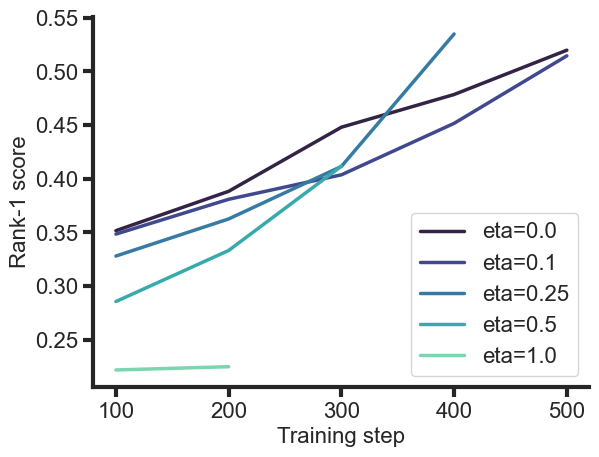

In [80]:
def rank1_score(matrix):
    _, s, _ = np.linalg.svd(matrix)
    return s[0]**2 / np.sum(s**2)

sns.set_palette("mako", n_colors=len(etas))

for eta in etas:
    if eta == 0.0:
        result_files = glob.glob(f'rnn_results/{results_dir}/zeroint{zeroint}_delay{delay}_vanilla1.0_sigma{sigma}_seed*')
    else:
        result_files = glob.glob(f'rnn_results/{results_dir}/zeroint{zeroint}_delay{delay}_normal_eta{eta}_sigma{sigma}_seed*')

    # key -> list of scores across dirs
    scores_by_key = defaultdict(list)

    for dir in result_files:
        for key, val in dd[eta][dir].items():
            if key in ['n_trials', 'best']:
                continue

            mat = val['hh.weight'].detach().cpu().numpy()
            score = rank1_score(mat)

            scores_by_key[key].append(score)

    # aggregate
    keys_sorted = sorted(scores_by_key.keys())
    means = [1-np.mean(scores_by_key[k]) for k in keys_sorted]

    plt.plot(keys_sorted, means, label=f'eta={eta}')

plt.xlabel('Training step')
plt.ylabel('Rank-1 score')
plt.legend()